d:\Rakib\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version : 2.9.1+cu130
CUDA available  : True
Selected device : cuda
GPU name        : NVIDIA GeForce RTX 5060 Ti
Output folder   : D:\Rakib\final\Outputs_task4_ssl1_simclr\task6_embedding_analysis
Total images  : 4479
Total classes : 44


,path,label_name,label
0,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
1,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
2,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
3,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0
4,C:\Users\User\Desktop\Brain Cancer\Astrocitoma...,Astrocitoma T1,0


Minimum samples in any class: 17


label_name
Granuloma T2          17
Ganglioglioma T1C+    18
Ganglioglioma T1      20
Ganglioglioma T2      23
Meduloblastoma T1     23
Germinoma T1          27
Tuberculoma T1        28
Granuloma T1          30
Granuloma T1C+        31
Tuberculoma T2        33
Name: count, dtype: int64

Train size: 3628
Val size  : 403
Test size : 448
Frozen encoder loaded.
Backbone used : resnet18
Feature dimension: 512
Feature sanity check: torch.Size([16, 512])

Extracting train/val/test features...
Train features: (3628, 512)
Val features  : (403, 512)
Test features : (448, 512)
Silhouette score: -0.19106118381023407


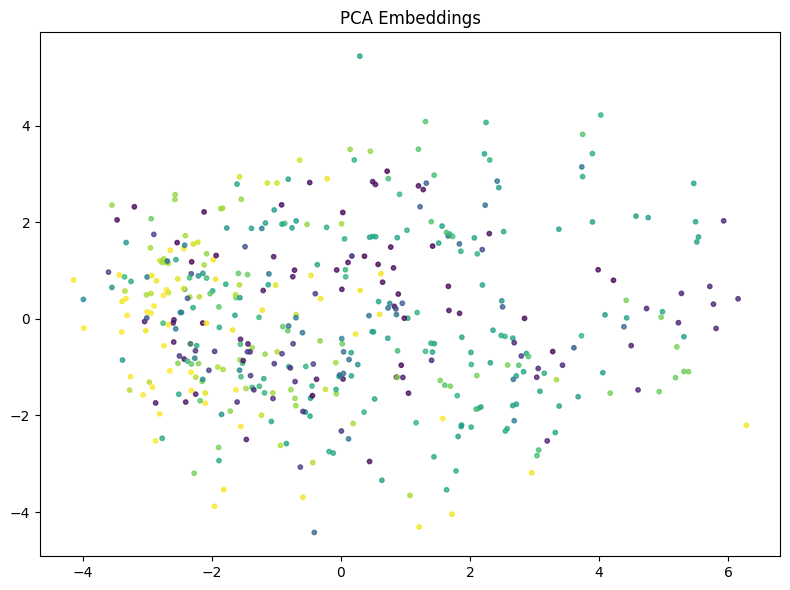

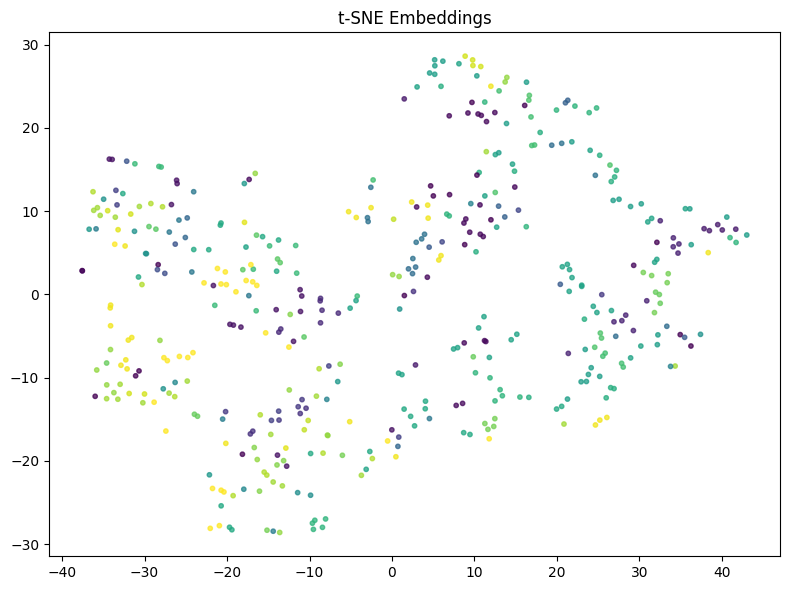

d:\Rakib\final\.venv\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


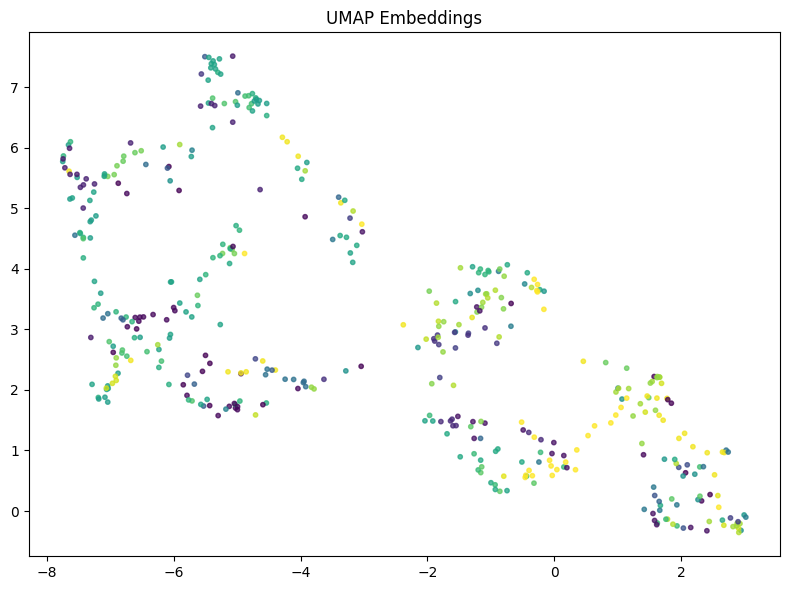

k-NN results: {'knn@1': 0.8683035714285714, 'knn@5': 0.7209821428571429, 'knn@20': 0.5915178571428571}


C:\Users\User\AppData\Local\Temp\ipykernel_2372\1245156579.py:443: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(len(x) * frac)), random_state=seed))


Label fraction 0.01 | samples=48 | best_val_acc=0.1017


C:\Users\User\AppData\Local\Temp\ipykernel_2372\1245156579.py:443: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(len(x) * frac)), random_state=seed))


Label fraction 0.05 | samples=165 | best_val_acc=0.0620


...

Label fraction 0.10 | samples=341 | best_val_acc=0.1017


C:\Users\User\AppData\Local\Temp\ipykernel_2372\1245156579.py:443: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(len(x) * frac)), random_state=seed))


Label fraction 0.25 | samples=890 | best_val_acc=0.1315


C:\Users\User\AppData\Local\Temp\ipykernel_2372\1245156579.py:443: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(len(x) * frac)), random_state=seed))


Label fraction 0.50 | samples=1800 | best_val_acc=0.1687


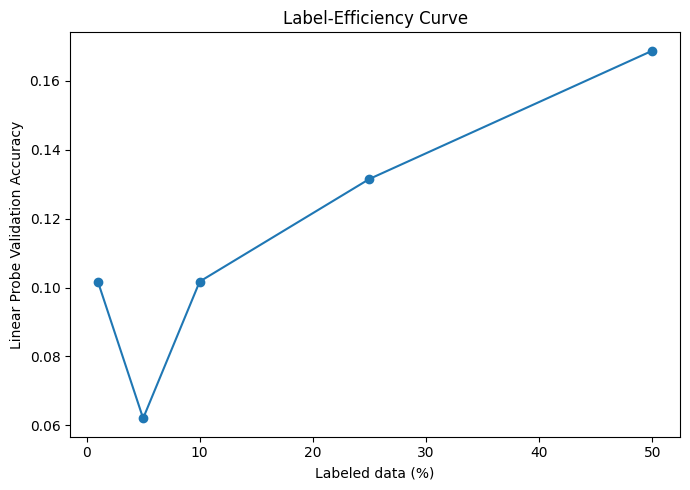


================ TASK 6 COMPLETE ================

Used local GPU: True
Summary saved : D:\Rakib\final\Outputs_task4_ssl1_simclr\task6_embedding_analysis\task6_summary.json
kNN table saved: D:\Rakib\final\Outputs_task4_ssl1_simclr\task6_embedding_analysis\task6_knn_silhouette_table.csv


,Metric,Value
0,k-NN @1,0.8683
1,k-NN @5,0.7210
2,k-NN @20,0.5915
3,Silhouette Score,-0.1911


,labeled_fraction,samples,best_val_acc
0,0.01,48,0.101737
1,0.05,165,0.062035
2,0.10,341,0.101737
3,0.25,890,0.131514
4,0.50,1800,0.168734


In [1]:
# ============================================================
# TASK 6 ONLY — Embedding Analysis for SSL-1 Encoder
# Stable VS Code / Windows / local GPU one-cell notebook
# ============================================================

import os
import sys
import json
import time
import random
import subprocess
import importlib.util
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, Any

import sys, subprocess, importlib.util

def ensure_package(pkg_name: str, pip_name: str = None):
    pip_name = pip_name or pkg_name
    if importlib.util.find_spec(pkg_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

# Force compatible versions
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "scikit-learn==1.4.2", "umap-learn==0.5.6", "timm==1.0.9"])
# ------------------------------------------------------------
# 1) Imports
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
import umap.umap_ as umap

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------------------------------------
# 2) Config
# ------------------------------------------------------------
@dataclass
class CFG:
    DATA_DIR: str = r"C:\Users\User\Desktop\Brain Cancer"
    OUT_DIR: str = r"D:\Rakib\final\Outputs_task4_ssl1_simclr\task6_embedding_analysis"
    FROZEN_ENCODER_PATH: str = r"D:\Rakib\final\Outputs_task4_ssl1_simclr\simclr_frozen_encoder.pth"

    seed: int = 42

    # same split style as Task 4 and Task 5
    train_pct: int = 90
    test_pct: int = 10
    val_in_train: float = 0.10

    # safe local settings
    img_size: int = 160
    batch_size_sup: int = 16
    num_workers: int = 0

    # MUST match Task 4 exactly
    backbone: str = "resnet18"

    # label-efficiency linear probe
    probe_epochs: int = 5
    probe_lr: float = 1e-3

    # plotting / analysis safety
    max_points_for_plot: int = 2000
    tsne_perplexity: int = 20

cfg = CFG()
os.makedirs(cfg.OUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 3) Device check
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = torch.cuda.is_available()

print("=" * 72)
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Selected device :", DEVICE)
if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
print("Output folder   :", cfg.OUT_DIR)
print("=" * 72)

# ------------------------------------------------------------
# 4) Reproducibility
# ------------------------------------------------------------
def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.seed)

# ------------------------------------------------------------
# 5) Path checks
# ------------------------------------------------------------
assert os.path.exists(cfg.DATA_DIR), f"DATA_DIR not found:\n{cfg.DATA_DIR}"
assert os.path.exists(cfg.FROZEN_ENCODER_PATH), (
    f"Frozen encoder not found:\n{cfg.FROZEN_ENCODER_PATH}\n"
    f"Run Task 4 first or fix the path."
)

# ------------------------------------------------------------
# 6) Scan dataset safely
# ------------------------------------------------------------
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def scan_dataset(root: str) -> pd.DataFrame:
    rows = []
    root = Path(root)

    exclude_dirs = {
        "task4_ssl1_simclr",
        "task5_downstream_simclr",
        "task6_embedding_analysis",
        "__pycache__",
        ".ipynb_checkpoints",
        ".venv",
        "venv",
    }

    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            if any(part in exclude_dirs for part in p.parts):
                continue
            rows.append((str(p), p.parent.name))

    return pd.DataFrame(rows, columns=["path", "label_name"])

df = scan_dataset(cfg.DATA_DIR)
assert len(df) > 0, f"No images found under {cfg.DATA_DIR}"

label_names = sorted(df["label_name"].unique().tolist())
label_to_idx = {name: i for i, name in enumerate(label_names)}
idx_to_label = {i: name for name, i in label_to_idx.items()}
df["label"] = df["label_name"].map(label_to_idx).astype(int)
num_classes = len(label_names)

print("Total images  :", len(df))
print("Total classes :", num_classes)
display(df.head())

# sanity check for rare classes
class_counts = df["label_name"].value_counts().sort_values()
print("Minimum samples in any class:", int(class_counts.min()))
display(class_counts.head(10))

# ------------------------------------------------------------
# 7) Split
# ------------------------------------------------------------
def make_split(df_all: pd.DataFrame, seed: int):
    test_ratio = cfg.test_pct / 100.0
    train_all, test_df = train_test_split(
        df_all,
        test_size=test_ratio,
        random_state=seed,
        stratify=df_all["label"]
    )
    val_df, train_df = train_test_split(
        train_all,
        test_size=(1 - cfg.val_in_train),
        random_state=seed,
        stratify=train_all["label"]
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = make_split(df, cfg.seed)

print("Train size:", len(train_df))
print("Val size  :", len(val_df))
print("Test size :", len(test_df))

with open(os.path.join(cfg.OUT_DIR, "task6_split_manifest.json"), "w", encoding="utf-8") as f:
    json.dump({
        "seed": cfg.seed,
        "train_pct": cfg.train_pct,
        "test_pct": cfg.test_pct,
        "val_in_train": cfg.val_in_train,
        "label_to_idx": label_to_idx,
        "train_paths": train_df["path"].tolist(),
        "val_paths": val_df["path"].tolist(),
        "test_paths": test_df["path"].tolist()
    }, f, indent=2)

# ------------------------------------------------------------
# 8) Transform / dataset
# ------------------------------------------------------------
normalize = transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)

eval_transform = transforms.Compose([
    transforms.Resize(int(cfg.img_size * 1.15)),
    transforms.CenterCrop(cfg.img_size),
    transforms.ToTensor(),
    normalize
])

class ImgDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths = df["path"].tolist()
        self.labels = df["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(p).convert("RGB")
        x = self.transform(img)
        return x, y, p

train_ds = ImgDataset(train_df, eval_transform)
val_ds = ImgDataset(val_df, eval_transform)
test_ds = ImgDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size_sup,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=PIN_MEMORY
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size_sup,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=PIN_MEMORY
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size_sup,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=PIN_MEMORY
)

# ------------------------------------------------------------
# 9) Load frozen encoder
# ------------------------------------------------------------
def get_encoder(backbone_name: str):
    encoder = timm.create_model(
        backbone_name,
        pretrained=False,
        num_classes=0,
        global_pool="avg"
    )
    feat_dim = encoder.num_features
    return encoder, feat_dim

encoder, feat_dim = get_encoder(cfg.backbone)
encoder.load_state_dict(torch.load(cfg.FROZEN_ENCODER_PATH, map_location="cpu"))
encoder = encoder.to(DEVICE).eval()

print("Frozen encoder loaded.")
print("Backbone used :", cfg.backbone)
print("Feature dimension:", feat_dim)

# quick sanity check
x_chk, y_chk, p_chk = next(iter(train_loader))
with torch.no_grad():
    h_chk = encoder(x_chk.to(DEVICE))
print("Feature sanity check:", h_chk.shape)

# ------------------------------------------------------------
# 10) Feature extraction
# ------------------------------------------------------------
@torch.no_grad()
def extract_features(encoder, loader):
    encoder.eval()
    feats, ys, paths = [], [], []
    for x, y, p in loader:
        x = x.to(DEVICE, non_blocking=True)
        h = encoder(x)
        feats.append(h.cpu().numpy())
        ys.append(y.numpy())
        paths.extend(list(p))
    return np.concatenate(feats, axis=0), np.concatenate(ys, axis=0), paths

print("\nExtracting train/val/test features...")
Xtr, ytr, ptr = extract_features(encoder, train_loader)
Xva, yva, pva = extract_features(encoder, val_loader)
Xte, yte, pte = extract_features(encoder, test_loader)

print("Train features:", Xtr.shape)
print("Val features  :", Xva.shape)
print("Test features :", Xte.shape)

# ------------------------------------------------------------
# 11) Save raw embeddings
# ------------------------------------------------------------
np.save(os.path.join(cfg.OUT_DIR, "X_train.npy"), Xtr)
np.save(os.path.join(cfg.OUT_DIR, "y_train.npy"), ytr)
np.save(os.path.join(cfg.OUT_DIR, "X_val.npy"), Xva)
np.save(os.path.join(cfg.OUT_DIR, "y_val.npy"), yva)
np.save(os.path.join(cfg.OUT_DIR, "X_test.npy"), Xte)
np.save(os.path.join(cfg.OUT_DIR, "y_test.npy"), yte)

# ------------------------------------------------------------
# 12) Dimensionality reduction helpers
# ------------------------------------------------------------
def safe_sample_for_plot(X, y, max_points, seed):
    if len(y) <= max_points:
        return X, y
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(y), size=max_points, replace=False)
    return X[idx], y[idx]

def plot_2d(emb, y, title, save_path):
    emb_plot, y_plot = safe_sample_for_plot(emb, y, cfg.max_points_for_plot, cfg.seed)
    plt.figure(figsize=(8, 6))
    plt.scatter(emb_plot[:, 0], emb_plot[:, 1], c=y_plot, s=10, alpha=0.75)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

# ------------------------------------------------------------
# 13) PCA / t-SNE / UMAP / Silhouette
# ------------------------------------------------------------
X_embed = Xte
y_embed = yte

# PCA 50 for low-dim analysis
n_pca = min(50, X_embed.shape[1], len(X_embed))
pca_50 = PCA(n_components=n_pca, random_state=cfg.seed).fit_transform(X_embed)

# silhouette can be slow, so do it on sampled data if very large
X_sil, y_sil = safe_sample_for_plot(pca_50, y_embed, 2000, cfg.seed)
sil_score = float(silhouette_score(X_sil, y_sil))
print("Silhouette score:", sil_score)

# PCA 2D
pca_2 = PCA(n_components=2, random_state=cfg.seed).fit_transform(X_embed)
plot_2d(pca_2, y_embed, "PCA Embeddings", os.path.join(cfg.OUT_DIR, "embedding_pca.png"))

# t-SNE 2D on sampled PCA space for stability
X_tsne_input, y_tsne_input = safe_sample_for_plot(pca_50, y_embed, cfg.max_points_for_plot, cfg.seed)
tsne_2 = TSNE(
    n_components=2,
    random_state=cfg.seed,
    init="pca",
    learning_rate="auto",
    perplexity=min(cfg.tsne_perplexity, max(5, len(X_tsne_input) // 10))
).fit_transform(X_tsne_input)
plot_2d(tsne_2, y_tsne_input, "t-SNE Embeddings", os.path.join(cfg.OUT_DIR, "embedding_tsne.png"))

# UMAP 2D on same sampled PCA input
umap_2 = umap.UMAP(n_components=2, random_state=cfg.seed).fit_transform(X_tsne_input)
plot_2d(umap_2, y_tsne_input, "UMAP Embeddings", os.path.join(cfg.OUT_DIR, "embedding_umap.png"))

# Save reduced embeddings
np.save(os.path.join(cfg.OUT_DIR, "pca_2.npy"), pca_2)
np.save(os.path.join(cfg.OUT_DIR, "tsne_2.npy"), tsne_2)
np.save(os.path.join(cfg.OUT_DIR, "umap_2.npy"), umap_2)

# ------------------------------------------------------------
# 14) k-NN in embedding space
# ------------------------------------------------------------
knn_results = {}
for k in [1, 5, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr, ytr)
    pred = knn.predict(Xte)
    knn_results[f"knn@{k}"] = float(accuracy_score(yte, pred))

print("k-NN results:", knn_results)

# ------------------------------------------------------------
# 15) Label-efficiency curve
# ------------------------------------------------------------
class LinearProbe(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        return self.fc(x)

def train_probe(X_train, y_train, X_val, y_val, epochs, lr):
    model = LinearProbe(X_train.shape[1], num_classes).to(DEVICE)

    X_train_t = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.long, device=DEVICE)
    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.long, device=DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    best_acc = -1.0

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(X_train_t.size(0), device=DEVICE)
        bs = 256

        for i in range(0, X_train_t.size(0), bs):
            idx = perm[i:i+bs]
            xb, yb = X_train_t[idx], y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = nn.CrossEntropyLoss()(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_pred = val_logits.argmax(dim=1)
            val_acc = float((val_pred == y_val_t).float().mean().item())

        if val_acc > best_acc:
            best_acc = val_acc

    return best_acc

def stratified_subsample(df_in, frac, seed):
    if frac >= 1.0:
        return df_in.copy()
    return (
        df_in.groupby("label", group_keys=False)
        .apply(lambda x: x.sample(max(1, int(len(x) * frac)), random_state=seed))
        .reset_index(drop=True)
    )

label_eff_rows = []
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]

for frac in fractions:
    sub_df = stratified_subsample(train_df, frac, cfg.seed)

    # guard against tiny subset
    if len(sub_df["label"].unique()) < num_classes:
        print(f"Skipping {frac:.2f} because not all classes are present in the subsample.")
        label_eff_rows.append({
            "labeled_fraction": frac,
            "samples": len(sub_df),
            "best_val_acc": None
        })
        continue

    sub_loader = DataLoader(
        ImgDataset(sub_df, eval_transform),
        batch_size=cfg.batch_size_sup,
        shuffle=False,
        num_workers=cfg.num_workers,
        pin_memory=PIN_MEMORY
    )

    Xsub, ysub, _ = extract_features(encoder, sub_loader)
    best_val_acc = train_probe(Xsub, ysub, Xva, yva, cfg.probe_epochs, cfg.probe_lr)

    label_eff_rows.append({
        "labeled_fraction": frac,
        "samples": len(sub_df),
        "best_val_acc": best_val_acc
    })
    print(f"Label fraction {frac:.2f} | samples={len(sub_df)} | best_val_acc={best_val_acc:.4f}")

label_eff_df = pd.DataFrame(label_eff_rows)
label_eff_df.to_csv(os.path.join(cfg.OUT_DIR, "label_efficiency.csv"), index=False)

plot_df = label_eff_df.dropna(subset=["best_val_acc"]).copy()
plt.figure(figsize=(7, 5))
plt.plot(plot_df["labeled_fraction"] * 100, plot_df["best_val_acc"], marker="o")
plt.xlabel("Labeled data (%)")
plt.ylabel("Linear Probe Validation Accuracy")
plt.title("Label-Efficiency Curve")
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUT_DIR, "label_efficiency_curve.png"), dpi=200)
plt.show()

# ------------------------------------------------------------
# 16) Save summary
# ------------------------------------------------------------
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

summary = {
    "task": "Task 6",
    "description": "Embedding analysis for frozen SSL encoder",
    "backbone": cfg.backbone,
    "img_size": cfg.img_size,
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "used_local_gpu": bool(torch.cuda.is_available()),
    "split": f"{cfg.train_pct}:{cfg.test_pct}",
    "feature_shapes": {
        "train": list(Xtr.shape),
        "val": list(Xva.shape),
        "test": list(Xte.shape),
    },
    "silhouette_score": sil_score,
    "knn_results": knn_results,
    "label_efficiency": label_eff_rows,
    "artifacts": {
        "pca_plot": os.path.join(cfg.OUT_DIR, "embedding_pca.png"),
        "tsne_plot": os.path.join(cfg.OUT_DIR, "embedding_tsne.png"),
        "umap_plot": os.path.join(cfg.OUT_DIR, "embedding_umap.png"),
        "label_efficiency_curve": os.path.join(cfg.OUT_DIR, "label_efficiency_curve.png"),
        "label_efficiency_csv": os.path.join(cfg.OUT_DIR, "label_efficiency.csv"),
    }
}

with open(os.path.join(cfg.OUT_DIR, "task6_summary.json"), "w", encoding="utf-8") as f:
    json.dump(to_jsonable(summary), f, indent=2)

# ------------------------------------------------------------
# 17) Final tables
# ------------------------------------------------------------
knn_table = pd.DataFrame([
    {"Metric": "k-NN @1", "Value": knn_results["knn@1"]},
    {"Metric": "k-NN @5", "Value": knn_results["knn@5"]},
    {"Metric": "k-NN @20", "Value": knn_results["knn@20"]},
    {"Metric": "Silhouette Score", "Value": sil_score},
])

knn_table["Value"] = pd.to_numeric(knn_table["Value"], errors="coerce").round(4)
knn_table.to_csv(os.path.join(cfg.OUT_DIR, "task6_knn_silhouette_table.csv"), index=False)

print("\n================ TASK 6 COMPLETE ================\n")
print("Used local GPU:", torch.cuda.is_available())
print("Summary saved :", os.path.join(cfg.OUT_DIR, "task6_summary.json"))
print("kNN table saved:", os.path.join(cfg.OUT_DIR, "task6_knn_silhouette_table.csv"))
display(knn_table)
display(label_eff_df)